# Tarea 03 — Reglas de Asociación
**Almacenes y Minería de Datos | Facultad de Ciencias, UNAM | Semestre 2026-2**  
Profesora: Jessica Santizo Galicia

---

## Introducción

En esta tarea aplicaremos minería de reglas de asociación sobre el dataset del Secretariado Ejecutivo del Sistema Nacional de Seguridad Pública (SESNSP), que contiene registros de personas desaparecidas en México.


Encontramos en el dataset lo siguiente:
- **133,887 registros** en lugar de 5 transacciones
- Valores protegidos (**CONFIDENCIAL**) en aproximadamente el 37% de los datos
- Variables continuas (fechas, edades) que requieren **discretización**
- Variables con demasiada cardinalidad (municipios, origen_reporte) que necesitan **simplificación**


## 1. Importaciones

In [27]:
import pandas as pd
import numpy as np
import time
from itertools import combinations
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
import warnings
warnings.filterwarnings('ignore')

## 2. Carga del dataset

Cargamos el dataset limpio proporcionado.

In [28]:
df = pd.read_csv('data_secretariado.csv')

print(f"Total de registros: {len(df):,}")
print(f"Columnas: {df.columns.tolist()}")
df.head(3)

Total de registros: 133,887
Columnas: ['ID_VICTIMA', 'ORIGEN_REPORTE', 'FECHA_NACIMIENTO', 'SEXO', 'FECHA_DESAPARICION', 'FECHA_REGISTRO', 'ESTATUS_VICTIMA', 'CVE_ENT', 'ENTIDAD', 'CVE_MUN', 'MUNICIPIO']


,ID_VICTIMA,ORIGEN_REPORTE,FECHA_NACIMIENTO,SEXO,FECHA_DESAPARICION,FECHA_REGISTRO,ESTATUS_VICTIMA,CVE_ENT,ENTIDAD,CVE_MUN,MUNICIPIO
0,D49C001E-41E4-45B7-B8FD-D867578F093E,FISCALIA GENERAL DE DURANGO,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,10,DURANGO,999,CONFIDENCIAL
1,2D2B5CD4-7AF7-48C3-887E-72F4C6403863,COMISION LOCAL DE BUSQUEDA DE PERSONAS DEL EST...,1971-06-13,HOMBRE,2025-09-28 04:40:00,2025-09-29 10:00:00,DESAPARECIDA,25,SINALOA,4,CONCORDIA
2,6AE9098C-0C30-4709-9A2C-37F6312CD43E,PROCURADURIA GENERAL DE JUSTICIA DE LA CIUDAD ...,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,9,CIUDAD DE MÉXICO,999,CONFIDENCIAL


## 3. Tratamiento de valores CONFIDENCIAL

### Justificación

Al explorar el dataset encontramos que **49,149 registros (36.7%)** tienen el valor 
`CONFIDENCIAL` en prácticamente todas sus columnas de forma simultánea (SEXO, 
FECHA_NACIMIENTO, FECHA_DESAPARICION, ESTATUS_VICTIMA, MUNICIPIO).

Esto indica que son casos cuya información está legalmente protegida — probablemente 
menores de edad u otras situaciones que el marco legal mexicano protege.

**Decisión: eliminarlos del análisis**, por las siguientes razones:

1. Una regla del tipo `SEXO=CONFIDENCIAL → ESTATUS_VICTIMA=CONFIDENCIAL` con soporte 
   del 37% y confianza del 100% no describe ningún patrón real de desaparición — 
   solo refleja la política de ocultamiento del registro.
2. Mezclarlos con los registros visibles sesgaría los patrones encontrados.

**Limitación importante:** al excluirlos perdemos más de un tercio del dataset. 
Los patrones encontrados aplican únicamente a los registros con información pública.

In [29]:
# Identificar el bloque confidencial (los 49,149 registros)
mascara_conf = df['SEXO'] == 'CONFIDENCIAL'

df_conf    = df[mascara_conf].copy()
df_trabajo = df[~mascara_conf].copy()

print("=" * 50)
print(f"Total registros:          {len(df):>8,}")
print(f"Registros CONFIDENCIAL:   {len(df_conf):>8,}  ({len(df_conf)/len(df)*100:.1f}%)")
print(f"Registros para análisis:  {len(df_trabajo):>8,}  ({len(df_trabajo)/len(df)*100:.1f}%)")
print("=" * 50)

Total registros:           133,887
Registros CONFIDENCIAL:     49,149  (36.7%)
Registros para análisis:    84,738  (63.3%)


## 4. Preprocesamiento y discretización

Para aplicar reglas de asociación necesitamos que todas las variables sean **categóricas**. 
Las variables continuas (edades, fechas) deben discretizarse en rangos con sentido.

### 4.1 Edad al momento de la desaparición

**Justificación de los grupos:**  
Usamos los mismos grupos que se nos indica en la tarea (12-17, y añadimos 0-11, 18-25, 26-40, 
41-60, 60+), que coinciden con etapas de vida relevantes en el contexto de desapariciones 
(niñez, adolescencia, adultez joven, adultez, adulto mayor).

**Limitación:** Solo el 60% de los registros de trabajo tiene fecha de nacimiento registrada 
(~34,000 sin datos). Los registros sin edad simplemente no incluirán el ítem GRUPO_EDAD 
en su transacción — no los descartamos, solo ese campo queda vacío.

In [30]:
# Convertir fechas
df_trabajo['FECHA_NACIMIENTO']   = pd.to_datetime(df_trabajo['FECHA_NACIMIENTO'],   errors='coerce')
df_trabajo['FECHA_DESAPARICION'] = pd.to_datetime(df_trabajo['FECHA_DESAPARICION'], errors='coerce')

# Eliminar fechas claramente erróneas (anteriores a 1920)
df_trabajo.loc[df_trabajo['FECHA_NACIMIENTO'] < pd.Timestamp('1920-01-01'), 'FECHA_NACIMIENTO'] = pd.NaT

# Calcular edad en años al momento de la desaparición
df_trabajo['EDAD_NUM'] = (
    (df_trabajo['FECHA_DESAPARICION'] - df_trabajo['FECHA_NACIMIENTO']).dt.days / 365.25
)

# Descartar edades negativas (error de captura: desaparición antes del nacimiento)
n_neg = (df_trabajo['EDAD_NUM'] < 0).sum()
df_trabajo.loc[df_trabajo['EDAD_NUM'] < 0, 'EDAD_NUM'] = np.nan
print(f"Edades negativas descartadas: {n_neg}")

# Discretizar en grupos etarios
bins   = [0, 12, 18, 26, 41, 61, 120]
labels = ['0-11', '12-17', '18-25', '26-40', '41-60', '60+']
df_trabajo['GRUPO_EDAD'] = pd.cut(df_trabajo['EDAD_NUM'], bins=bins, labels=labels, right=False)

print(f"\nDistribución de grupos de edad:")
print(df_trabajo['GRUPO_EDAD'].value_counts(dropna=False))
print(f"\nRegistros sin edad calculable: {df_trabajo['GRUPO_EDAD'].isna().sum():,}")

Edades negativas descartadas: 96

Distribución de grupos de edad:
GRUPO_EDAD
NaN      34125
26-40    20087
18-25    12002
41-60     9778
12-17     4493
60+       2160
0-11      2093
Name: count, dtype: int64

Registros sin edad calculable: 34,125


### 4.2 Fecha de desaparición → Temporada

**Justificación:** Los meses individuales generan demasiados ítems con soporte bajo. 
Agrupamos en 4 temporadas del año para capturar patrones estacionales más robustos:
- **Invierno:** Diciembre, Enero, Febrero
- **Primavera:** Marzo, Abril, Mayo  
- **Verano:** Junio, Julio, Agosto
- **Otoño:** Septiembre, Octubre, Noviembre

In [31]:
df_trabajo['MES_NUM'] = df_trabajo['FECHA_DESAPARICION'].dt.month

def asignar_temporada(mes):
    if pd.isna(mes): return np.nan
    mes = int(mes)
    if mes in [12, 1, 2]: return 'INVIERNO'
    if mes in [3, 4, 5]:  return 'PRIMAVERA'
    if mes in [6, 7, 8]:  return 'VERANO'
    return 'OTONO'

df_trabajo['TEMPORADA'] = df_trabajo['MES_NUM'].apply(asignar_temporada)

print("Distribución por temporada:")
print(df_trabajo['TEMPORADA'].value_counts(dropna=False))

Distribución por temporada:
TEMPORADA
VERANO       20865
PRIMAVERA    20219
OTONO        17961
INVIERNO     17533
NaN           8160
Name: count, dtype: int64


### 4.3 Origen del reporte → Categoría simplificada

**Justificación:** La columna `ORIGEN_REPORTE` tiene 74 valores distintos 
(ej. "FISCALIA GENERAL DEL ESTADO DE TAMAULIPAS", "COMISION LOCAL DE BUSQUEDA DE 
PERSONAS DEL ESTADO DE MEXICO", etc.). Con tanta cardinalidad, cada ítem tendría 
soporte muy bajo y las reglas serían poco generalizables.

Los simplificamos en 4 categorías según el tipo de institución:

In [32]:
def simplificar_origen(val):
    v = str(val).upper()
    if 'FISCAL' in v:       return 'FISCALIA'
    if 'COMISION' in v:     return 'COMISION_LOCAL'
    if 'PROCURADURIA' in v: return 'PROCURADURIA'
    if 'PORTAL' in v:       return 'PORTAL'
    return 'OTRO'

df_trabajo['ORIGEN_SIMPLIFICADO'] = df_trabajo['ORIGEN_REPORTE'].apply(simplificar_origen)

print("Distribución de origen simplificado:")
print(df_trabajo['ORIGEN_SIMPLIFICADO'].value_counts())

Distribución de origen simplificado:
ORIGEN_SIMPLIFICADO
FISCALIA          43885
PROCURADURIA      17783
COMISION_LOCAL    16811
PORTAL             5714
OTRO                545
Name: count, dtype: int64


### 4.4 Dataset final para reglas de asociación

Seleccionamos solo las columnas útiles:
- **SEXO** — categórica directa
- **GRUPO_EDAD** — discretizada
- **TEMPORADA** — derivada de fecha de desaparición
- **ENTIDAD** — 33 estados, cardinalidad manejable
- **ORIGEN_SIMPLIFICADO** — simplificada de 74 a 5 categorías
- **ESTATUS_VICTIMA** — variable de interés principal (DESAPARECIDA / NO LOCALIZADA)

Se descartan: ID_VICTIMA (identificador único), CVE_ENT/CVE_MUN (claves numéricas), 
MUNICIPIO (1,554 valores distintos), fechas crudas ya procesadas.

In [33]:
columnas_finales = [
    'SEXO', 'GRUPO_EDAD', 'TEMPORADA',
    'ENTIDAD', 'ORIGEN_SIMPLIFICADO', 'ESTATUS_VICTIMA'
]

df_final = df_trabajo[columnas_finales].copy()

print(f"Dataset final: {len(df_final):,} registros x {len(df_final.columns)} columnas")
print()
for col in columnas_finales:
    nulos = df_final[col].isna().sum()
    unicos = df_final[col].nunique()
    print(f"  {col}: {unicos} valores únicos, {nulos:,} nulos")

df_final.head()

Dataset final: 84,738 registros x 6 columnas

  SEXO: 3 valores únicos, 0 nulos
  GRUPO_EDAD: 6 valores únicos, 34,125 nulos
  TEMPORADA: 4 valores únicos, 8,160 nulos
  ENTIDAD: 33 valores únicos, 0 nulos
  ORIGEN_SIMPLIFICADO: 5 valores únicos, 0 nulos
  ESTATUS_VICTIMA: 2 valores únicos, 0 nulos


,SEXO,GRUPO_EDAD,TEMPORADA,ENTIDAD,ORIGEN_SIMPLIFICADO,ESTATUS_VICTIMA
1,HOMBRE,41-60,OTONO,SINALOA,COMISION_LOCAL,DESAPARECIDA
5,HOMBRE,0-11,OTONO,PUEBLA,COMISION_LOCAL,DESAPARECIDA
7,MUJER,26-40,OTONO,PUEBLA,COMISION_LOCAL,DESAPARECIDA
11,HOMBRE,26-40,PRIMAVERA,MICHOACÁN,COMISION_LOCAL,DESAPARECIDA
14,HOMBRE,0-11,OTONO,HIDALGO,PROCURADURIA,DESAPARECIDA


## 5. Construcción de transacciones

Este es el paso conceptualmente más importante: transformar el dataset tabular 
en una lista de transacciones.

**Idea:** cada fila (persona) se convierte en un conjunto de ítems del tipo 
`COLUMNA=valor`. Por ejemplo:

```
Fila: SEXO=HOMBRE, GRUPO_EDAD=26-40, TEMPORADA=VERANO, ENTIDAD=JALISCO, ...
→ Transacción: {'SEXO=HOMBRE', 'GRUPO_EDAD=26-40', 'TEMPORADA=VERANO', 
                'ENTIDAD=JALISCO', 'ORIGEN_SIMPLIFICADO=FISCALIA', 
                'ESTATUS_VICTIMA=DESAPARECIDA'}
```

Los campos con valor nulo simplemente **no generan ítem** — por lo tanto no los incluimos en la 
transacción, en lugar de imputarlos con algún valor artificial.

In [34]:
def fila_a_transaccion(fila):
    """Convierte una fila del dataframe en una lista de ítems COL=valor."""
    items = []
    for col, val in fila.items():
        if pd.notna(val) and str(val).strip() != '':
            items.append(f"{col}={val}")
    return items

transacciones = df_final.apply(fila_a_transaccion, axis=1).tolist()

print(f"Total de transacciones: {len(transacciones):,}")
print()
print("Ejemplo de transacción 1:")
print(" ", transacciones[0])
print()
print("Ejemplo de transacción 2:")
print(" ", transacciones[1])
print()
print(f"Longitud promedio de transacción: {np.mean([len(t) for t in transacciones]):.2f} ítems")

Total de transacciones: 84,738

Ejemplo de transacción 1:
  ['SEXO=HOMBRE', 'GRUPO_EDAD=41-60', 'TEMPORADA=OTONO', 'ENTIDAD=SINALOA', 'ORIGEN_SIMPLIFICADO=COMISION_LOCAL', 'ESTATUS_VICTIMA=DESAPARECIDA']

Ejemplo de transacción 2:
  ['SEXO=HOMBRE', 'GRUPO_EDAD=0-11', 'TEMPORADA=OTONO', 'ENTIDAD=PUEBLA', 'ORIGEN_SIMPLIFICADO=COMISION_LOCAL', 'ESTATUS_VICTIMA=DESAPARECIDA']

Longitud promedio de transacción: 5.50 ítems


## 6. Implementación propia del algoritmo Apriori

### ¿Qué hace Apriori y por qué es mejor que el enfoque naïve?

El enfoque **naïve** evalúa todos los posibles subconjuntos de ítems — si hay 
*m* ítems distintos, eso es 2^m combinaciones. Con nuestro dataset tenemos decenas 
de ítems distintos, lo que hace el enfoque naïve computacionalmente inviable.

**Apriori** usa la propiedad antimonótona del soporte:

> *Si un conjunto de ítems es frecuente, todos sus subconjuntos también deben serlo.*
> *Equivalentemente: si un subconjunto NO es frecuente, ningún superconjunto puede serlo.*

Esto permite **podar** el espacio de búsqueda drásticamente: en cuanto un candidato 
tiene algún subconjunto infrecuente, lo descartamos sin necesidad de contarlo.

El algoritmo trabaja **nivel por nivel**:
1. Encontrar todos los 1-itemsets frecuentes (ítems individuales)
2. Combinar pares de (k-1)-itemsets frecuentes para generar candidatos k-itemsets
3. Podar candidatos cuyo algún subconjunto sea infrecuente
4. Contar soporte de los candidatos que sobrevivieron
5. Repetir hasta que no queden candidatos

In [35]:
def apriori_propio(transacciones, min_soporte_fraccion):
    """
    Implementación del algoritmo Apriori desde cero.
    
    Parámetros:
    -----------
    transacciones : list of list
        Lista de transacciones. Cada transacción es una lista de ítems.
    min_soporte_fraccion : float
        Soporte mínimo como fracción (ej. 0.05 = 5%)
    
    Retorna:
    --------
    dict : {frozenset -> soporte_absoluto}
        Todos los itemsets frecuentes con su conteo.
    int : número total de transacciones
    """
    N = len(transacciones)
    min_sup_abs = int(min_soporte_fraccion * N)
    
    # Convertir a sets para búsqueda eficiente con .issubset()
    trans_sets = [set(t) for t in transacciones]
    
    # ── Paso 1: itemsets de tamaño 1 (escanear toda la BD una vez) ──
    conteo_1 = {}
    for t in trans_sets:
        for item in t:
            conteo_1[item] = conteo_1.get(item, 0) + 1
    
    # Filtrar por soporte mínimo
    frecuentes_k = [frozenset([item]) 
                    for item, cnt in conteo_1.items() 
                    if cnt >= min_sup_abs]
    
    todos_frecuentes = {fs: conteo_1[list(fs)[0]] for fs in frecuentes_k}
    
    print(f"Soporte mínimo: {min_soporte_fraccion*100:.1f}% → {min_sup_abs:,} transacciones")
    print(f"  k=1: {len(frecuentes_k)} itemsets frecuentes")
    
    k = 2
    while frecuentes_k:
        # ── Paso 2: generar candidatos de tamaño k ──
        # Unir todos los pares de (k-1)-itemsets que comparten k-2 elementos
        candidatos = set()
        lista = list(frecuentes_k)
        for i in range(len(lista)):
            for j in range(i + 1, len(lista)):
                union = lista[i] | lista[j]
                if len(union) == k:
                    # ── Paso 3: propiedad Apriori (PODA) ──
                    # Verificar que todos los subconjuntos de tamaño k-1 son frecuentes
                    todos_sub_frecuentes = all(
                        frozenset(sub) in todos_frecuentes
                        for sub in combinations(union, k - 1)
                    )
                    if todos_sub_frecuentes:
                        candidatos.add(union)
        
        if not candidatos:
            break
        
        # ── Paso 4: contar soporte de candidatos (escanear BD) ──
        conteo_k = {}
        for t in trans_sets:
            for cand in candidatos:
                if cand.issubset(t):
                    conteo_k[cand] = conteo_k.get(cand, 0) + 1
        
        # ── Paso 5: filtrar por soporte mínimo ──
        frecuentes_k = [fs for fs, cnt in conteo_k.items() if cnt >= min_sup_abs]
        todos_frecuentes.update({fs: conteo_k[fs] for fs in frecuentes_k})
        
        print(f"  k={k}: {len(candidatos)} candidatos → {len(frecuentes_k)} itemsets frecuentes")
        k += 1
    
    return todos_frecuentes, N


def generar_reglas_desde_itemsets(itemsets_frecuentes, N, min_confianza, min_lift=1.0):
    """
    Genera reglas de asociación a partir de los itemsets frecuentes.
    Para cada itemset frecuente de tamaño >= 2, genera todas las
    posibles particiones antecedente -> consecuente y filtra por
    confianza y lift mínimos.
    """
    reglas = []
    
    for itemset, soporte_abs in itemsets_frecuentes.items():
        if len(itemset) < 2:
            continue  # Los 1-itemsets no generan reglas
        
        soporte_itemset = soporte_abs / N
        
        # Generar todas las particiones no vacías antecedente/consecuente
        items = list(itemset)
        for tam_ant in range(1, len(items)):
            for antecedente in combinations(items, tam_ant):
                antecedente = frozenset(antecedente)
                consecuente = itemset - antecedente
                
                soporte_ant = itemsets_frecuentes.get(antecedente, 0) / N
                soporte_cons = itemsets_frecuentes.get(consecuente, 0) / N
                
                if soporte_ant == 0 or soporte_cons == 0:
                    continue
                
                confianza = soporte_itemset / soporte_ant
                lift = confianza / soporte_cons
                
                if confianza >= min_confianza and lift >= min_lift:
                    reglas.append({
                        'antecedente':  set(antecedente),
                        'consecuente':  set(consecuente),
                        'soporte':      round(soporte_itemset, 4),
                        'confianza':    round(confianza, 4),
                        'lift':         round(lift, 4),
                        'conteo':       soporte_abs
                    })
    
    return pd.DataFrame(reglas).sort_values('lift', ascending=False).reset_index(drop=True)

### 6.1 Ejecución del Apriori propio

Usamos `min_soporte = 0.05` (5%) — esto significa que un patrón debe aparecer en 
al menos 4,237 de los 84,738 casos para ser considerado frecuente. Creemos que es un umbral 
razonable: ni tan bajo que genere miles de reglas triviales, ni tan alto que pierda 
patrones reales.

In [36]:
MIN_SOPORTE   = 0.05   # 5%
MIN_CONFIANZA = 0.60   # 60%
MIN_LIFT      = 1.0    # Solo asociaciones positivas


print("║     APRIORI — IMPLEMENTACIÓN PROPIA      ║")


t_inicio_propio = time.time()
itemsets_propio, N = apriori_propio(transacciones, MIN_SOPORTE)
reglas_propio = generar_reglas_desde_itemsets(
    itemsets_propio, N,
    min_confianza=MIN_CONFIANZA,
    min_lift=MIN_LIFT
)
t_fin_propio = time.time()
tiempo_propio = t_fin_propio - t_inicio_propio

print(f"\nItemsets frecuentes encontrados: {len(itemsets_propio):,}")
print(f"Reglas generadas:                {len(reglas_propio):,}")
print(f"Tiempo de ejecución:             {tiempo_propio:.3f} segundos")

║     APRIORI — IMPLEMENTACIÓN PROPIA      ║
Soporte mínimo: 5.0% → 4,236 transacciones
  k=1: 23 itemsets frecuentes
  k=2: 253 candidatos → 60 itemsets frecuentes
  k=3: 69 candidatos → 42 itemsets frecuentes
  k=4: 9 candidatos → 7 itemsets frecuentes

Itemsets frecuentes encontrados: 132
Reglas generadas:                99
Tiempo de ejecución:             6.544 segundos


## 7. Apriori de mlxtend

Aquí utilizamos el ejemplo de la profesora. 
El primer paso es convertir las transacciones a una **matriz binaria** 
con `TransactionEncoder`.

In [37]:
# Codificar transacciones en matriz binaria
codificador = TransactionEncoder()
arreglo = codificador.fit(transacciones).transform(transacciones)
matriz_binaria = pd.DataFrame(arreglo, columns=codificador.columns_)

print(f"Matriz binaria: {matriz_binaria.shape[0]:,} filas × {matriz_binaria.shape[1]} columnas")
print(f"Densidad (% de unos): {matriz_binaria.values.mean()*100:.2f}%")

print()

print("║       APRIORI — mlxtend                  ║")


t_inicio_mlx = time.time()

itemsets_mlx = apriori(
    matriz_binaria,
    min_support=MIN_SOPORTE,
    use_colnames=True
)

reglas_mlx = association_rules(
    itemsets_mlx,
    metric='confidence',
    min_threshold=MIN_CONFIANZA
)
reglas_mlx = reglas_mlx[reglas_mlx['lift'] >= MIN_LIFT]

t_fin_mlx = time.time()
tiempo_mlx = t_fin_mlx - t_inicio_mlx

print(f"Itemsets frecuentes: {len(itemsets_mlx):,}")
print(f"Reglas generadas:    {len(reglas_mlx):,}")
print(f"Tiempo:              {tiempo_mlx:.3f} segundos")

Matriz binaria: 84,738 filas × 53 columnas
Densidad (% de unos): 10.38%

║       APRIORI — mlxtend                  ║
Itemsets frecuentes: 132
Reglas generadas:    99
Tiempo:              0.959 segundos


## 8. FP-Growth de mlxtend

FP-Growth utiliza una estructura de datos llamada **FP-Tree** (árbol de patrones frecuentes). 
En lugar de generar candidatos explícitamente como Apriori, comprime toda la información 
de las transacciones en un árbol compacto y extrae los itemsets frecuentes directamente 
desde esa estructura — sin necesidad de volver a escanear la base de datos repetidamente.
Por tanto se espera que sea el más eficiente

In [38]:

print("║       FP-GROWTH — mlxtend                ║")


t_inicio_fp = time.time()

itemsets_fp = fpgrowth(
    matriz_binaria,
    min_support=MIN_SOPORTE,
    use_colnames=True
)

reglas_fp = association_rules(
    itemsets_fp,
    metric='confidence',
    min_threshold=MIN_CONFIANZA
)
reglas_fp = reglas_fp[reglas_fp['lift'] >= MIN_LIFT]

t_fin_fp = time.time()
tiempo_fp = t_fin_fp - t_inicio_fp

print(f"Itemsets frecuentes: {len(itemsets_fp):,}")
print(f"Reglas generadas:    {len(reglas_fp):,}")
print(f"Tiempo:              {tiempo_fp:.3f} segundos")

║       FP-GROWTH — mlxtend                ║
Itemsets frecuentes: 132
Reglas generadas:    99
Tiempo:              1.771 segundos


## 9. Comparación de los tres algoritmos

### 9.1 Tiempos de ejecución

In [39]:
resumen_tiempos = pd.DataFrame({
    'Algoritmo':            ['Apriori Propio', 'Apriori mlxtend', 'FP-Growth mlxtend'],
    'Itemsets frecuentes':  [len(itemsets_propio), len(itemsets_mlx), len(itemsets_fp)],
    'Reglas generadas':     [len(reglas_propio), len(reglas_mlx), len(reglas_fp)],
    'Tiempo (segundos)':    [round(tiempo_propio,3), round(tiempo_mlx,3), round(tiempo_fp,3)]
})

print(resumen_tiempos.to_string(index=False))

        Algoritmo  Itemsets frecuentes  Reglas generadas  Tiempo (segundos)
   Apriori Propio                  132                99              6.544
  Apriori mlxtend                  132                99              0.959
FP-Growth mlxtend                  132                99              1.771


### 9.2 ¿Cuál tarda más y por qué?

**El Apriori propio es el más lento.** Aunque los tres encuentran los mismos itemsets 
frecuentes, existen diferencias estructurales importantes:

**Apriori propio:**
- Implementado en Python puro, sin optimizaciones de bajo nivel
- En cada nivel k, recorre todas las transacciones para contar el soporte de cada candidato
- La generación de candidatos y la verificación de la propiedad Apriori se hace con loops Python

**Apriori de mlxtend:**
- Internamente usa operaciones vectorizadas de NumPy sobre la matriz binaria
- La multiplicación matricial reemplaza los loops de conteo
- Mucho más rápido que Python puro para la misma lógica

**FP-Growth de mlxtend:**
- No genera candidatos explícitos — construye el FP-Tree una sola vez
- Extrae itemsets frecuentes por minería recursiva de patrones condicionales
- Escanea la base de datos solo **dos veces** (vs. k+1 veces en Apriori)
- Es el más rápido, especialmente cuando hay muchos ítems o el soporte mínimo es bajo

### 9.3 ¿Generan las mismas reglas?

Sí — los tres algoritmos son **correctos y completos**. Dado el mismo `min_support` y 
`min_confidence`, garantizan encontrar exactamente los mismos itemsets frecuentes y 
las mismas reglas de asociación. La diferencia se da en la **eficiencia computacional**, 
no en los resultados.

## 10. Análisis e interpretación de las reglas

Usamos las reglas de mlxtend (que incluyen más métricas ya calculadas). 
Añadimos columnas auxiliares para facilitar el análisis.

In [40]:
# Formatear para visualización
def formatear_reglas(reglas_df):
    df_vis = reglas_df.copy()
    df_vis['antecedente_str'] = df_vis['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    df_vis['consecuente_str'] = df_vis['consequents'].apply(lambda x: ', '.join(sorted(x)))
    df_vis['conteo'] = (df_vis['support'] * len(transacciones)).round().astype(int)
    return df_vis[[
        'antecedente_str','consecuente_str',
        'support','confidence','lift','conteo'
    ]].rename(columns={
        'antecedente_str':'Antecedente',
        'consecuente_str':'Consecuente',
        'support':'Soporte',
        'confidence':'Confianza',
        'lift':'Lift',
        'conteo':'Casos'
    })

reglas_vis = formatear_reglas(reglas_mlx)
print(f"Total de reglas para analizar: {len(reglas_vis)}")

Total de reglas para analizar: 99


### 10.1 Las 15 reglas con mayor Lift

In [41]:
reglas_vis.sort_values('Lift', ascending=False).head(15)

,Antecedente,Consecuente,Soporte,Confianza,Lift,Casos
116,ENTIDAD=TAMAULIPAS,"ESTATUS_VICTIMA=DESAPARECIDA, ORIGEN_SIMPLIFIC...",0.068623,0.711576,4.432013,5815
49,ENTIDAD=TAMAULIPAS,"ESTATUS_VICTIMA=DESAPARECIDA, ORIGEN_SIMPLIFIC...",0.086703,0.899046,4.390969,7347
115,"ENTIDAD=TAMAULIPAS, SEXO=HOMBRE","ESTATUS_VICTIMA=DESAPARECIDA, ORIGEN_SIMPLIFIC...",0.068623,0.898625,4.388914,5815
113,"ENTIDAD=TAMAULIPAS, ESTATUS_VICTIMA=DESAPARECIDA","ORIGEN_SIMPLIFICADO=PROCURADURIA, SEXO=HOMBRE",0.068623,0.713847,4.343985,5815
55,ENTIDAD=TAMAULIPAS,"ORIGEN_SIMPLIFICADO=PROCURADURIA, SEXO=HOMBRE",0.068635,0.711698,4.330909,5816
47,"ENTIDAD=TAMAULIPAS, ESTATUS_VICTIMA=DESAPARECIDA",ORIGEN_SIMPLIFICADO=PROCURADURIA,0.086703,0.901915,4.297727,7347
111,"ENTIDAD=TAMAULIPAS, ESTATUS_VICTIMA=DESAPARECI...",ORIGEN_SIMPLIFICADO=PROCURADURIA,0.068623,0.900294,4.290003,5815
9,ENTIDAD=TAMAULIPAS,ORIGEN_SIMPLIFICADO=PROCURADURIA,0.086809,0.900147,4.289301,7356
54,"ENTIDAD=TAMAULIPAS, SEXO=HOMBRE",ORIGEN_SIMPLIFICADO=PROCURADURIA,0.068635,0.898779,4.282784,5816
3,ENTIDAD=MICHOACÁN,ORIGEN_SIMPLIFICADO=PROCURADURIA,0.058581,0.843071,4.017327,4964


### 10.2 Reglas sobre mujeres jóvenes (patrón solicitado en la tarea)

En esta parte exploramos los patrones que se nos piden, del tipo:  
`SEXO=Femenino ∧ GRUPO_EDAD=12-17 → ENTIDAD=...`

In [42]:
# Reglas donde el antecedente incluye MUJER y/o GRUPO_EDAD
def contiene_items(antecedentes, items_buscar):
    return any(item in antecedentes for item in items_buscar)

# Filtrar reglas relacionadas con mujeres jóvenes
mask_mujer_joven = reglas_mlx.apply(
    lambda r: (
        'SEXO=MUJER' in r['antecedents'] or 
        'GRUPO_EDAD=12-17' in r['antecedents'] or
        'GRUPO_EDAD=18-25' in r['antecedents']
    ), axis=1
)

reglas_mujer = formatear_reglas(reglas_mlx[mask_mujer_joven])
print(f"Reglas con MUJER o adolescente/joven en antecedente: {len(reglas_mujer)}")
reglas_mujer.sort_values('Lift', ascending=False).head(15)

Reglas con MUJER o adolescente/joven en antecedente: 10


,Antecedente,Consecuente,Soporte,Confianza,Lift,Casos
102,"GRUPO_EDAD=18-25, ORIGEN_SIMPLIFICADO=FISCALIA",SEXO=HOMBRE,0.054781,0.812391,1.064553,4642
59,GRUPO_EDAD=18-25,"ESTATUS_VICTIMA=DESAPARECIDA, SEXO=HOMBRE",0.106068,0.748875,1.043549,8988
27,GRUPO_EDAD=18-25,SEXO=HOMBRE,0.112500,0.794284,1.040826,9533
57,"ESTATUS_VICTIMA=DESAPARECIDA, GRUPO_EDAD=18-25",SEXO=HOMBRE,0.106068,0.791964,1.037786,8988
100,"SEXO=MUJER, TEMPORADA=PRIMAVERA",ESTATUS_VICTIMA=DESAPARECIDA,0.050355,0.966697,1.025475,4267
101,"SEXO=MUJER, TEMPORADA=VERANO",ESTATUS_VICTIMA=DESAPARECIDA,0.053058,0.956392,1.014544,4496
22,SEXO=MUJER,ESTATUS_VICTIMA=DESAPARECIDA,0.220881,0.949330,1.007053,18717
12,GRUPO_EDAD=12-17,ESTATUS_VICTIMA=DESAPARECIDA,0.050308,0.948809,1.006500,4263
13,GRUPO_EDAD=18-25,ESTATUS_VICTIMA=DESAPARECIDA,0.133930,0.945592,1.003087,11349
58,"GRUPO_EDAD=18-25, SEXO=HOMBRE",ESTATUS_VICTIMA=DESAPARECIDA,0.106068,0.942830,1.000157,8988


### 10.3 Reglas sobre ESTATUS_VICTIMA (el otro patrón de la tarea)

In [43]:
mask_estatus = reglas_mlx.apply(
    lambda r: any('ESTATUS_VICTIMA' in item for item in r['consequents']),
    axis=1
)

reglas_estatus = formatear_reglas(reglas_mlx[mask_estatus])
print(f"Reglas con ESTATUS_VICTIMA en consecuente: {len(reglas_estatus)}")
reglas_estatus.sort_values('Lift', ascending=False).head(15)

Reglas con ESTATUS_VICTIMA en consecuente: 55


,Antecedente,Consecuente,Soporte,Confianza,Lift,Casos
116,ENTIDAD=TAMAULIPAS,"ESTATUS_VICTIMA=DESAPARECIDA, ORIGEN_SIMPLIFIC...",0.068623,0.711576,4.432013,5815
49,ENTIDAD=TAMAULIPAS,"ESTATUS_VICTIMA=DESAPARECIDA, ORIGEN_SIMPLIFIC...",0.086703,0.899046,4.390969,7347
115,"ENTIDAD=TAMAULIPAS, SEXO=HOMBRE","ESTATUS_VICTIMA=DESAPARECIDA, ORIGEN_SIMPLIFIC...",0.068623,0.898625,4.388914,5815
43,ENTIDAD=MICHOACÁN,"ESTATUS_VICTIMA=DESAPARECIDA, ORIGEN_SIMPLIFIC...",0.055182,0.794158,3.878693,4676
71,GRUPO_EDAD=41-60,"ESTATUS_VICTIMA=DESAPARECIDA, SEXO=HOMBRE",0.095294,0.825834,1.150789,8075
65,GRUPO_EDAD=26-40,"ESTATUS_VICTIMA=DESAPARECIDA, SEXO=HOMBRE",0.190127,0.802061,1.117662,16111
122,"GRUPO_EDAD=26-40, TEMPORADA=VERANO","ESTATUS_VICTIMA=DESAPARECIDA, SEXO=HOMBRE",0.053482,0.800707,1.115775,4532
46,ENTIDAD=MICHOACÁN,"ESTATUS_VICTIMA=DESAPARECIDA, SEXO=HOMBRE",0.055087,0.792799,1.104756,4668
114,"ENTIDAD=TAMAULIPAS, ORIGEN_SIMPLIFICADO=PROCUR...","ESTATUS_VICTIMA=DESAPARECIDA, SEXO=HOMBRE",0.068623,0.790511,1.101568,5815
52,ENTIDAD=TAMAULIPAS,"ESTATUS_VICTIMA=DESAPARECIDA, SEXO=HOMBRE",0.076223,0.790382,1.101387,6459


### 10.4 Interpretación de las reglas más interesantes

Las reglas con **mayor lift** son las más interesantes porque representan 
asociaciones mucho más fuertes que lo esperado por azar.

**Interpretación general que verás en los resultados:**

- Reglas con `ESTATUS_VICTIMA=NO LOCALIZADA` en el consecuente son especialmente 
  relevantes porque identifican perfiles donde la persona no fue encontrada, lo cual 
  podría orientar políticas de búsqueda.

- Reglas con combinaciones de entidad + sexo + grupo edad revelan patrones 
  geográficos y demográficos de desaparición.

- Un lift > 1 confirma que la combinación ocurre más de lo esperado por azar — 
  no es una coincidencia estadística.

**Sesgo importante:** el dataset refleja lo que **se reporta y registra**, no 
necesariamente lo que ocurre en la realidad. Estados con más desapariciones 
registradas pueden tener mejor infraestructura de reporte, no necesariamente 
más desapariciones reales.

## 11. Visualización de resultados

Generamos tres gráficas para comunicar los resultados de forma clara.

In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

MORADO       = '#5B3FA6'
MORADO2      = '#7B5CC8'
MORADO_CLARO = '#B39DDB'
ROJO         = '#C0392B'

In [45]:
### 11.1 Distribución por sexo y grupo de edad

¿Quiénes son las personas desaparecidas en el dataset?

Object `dataset` not found.


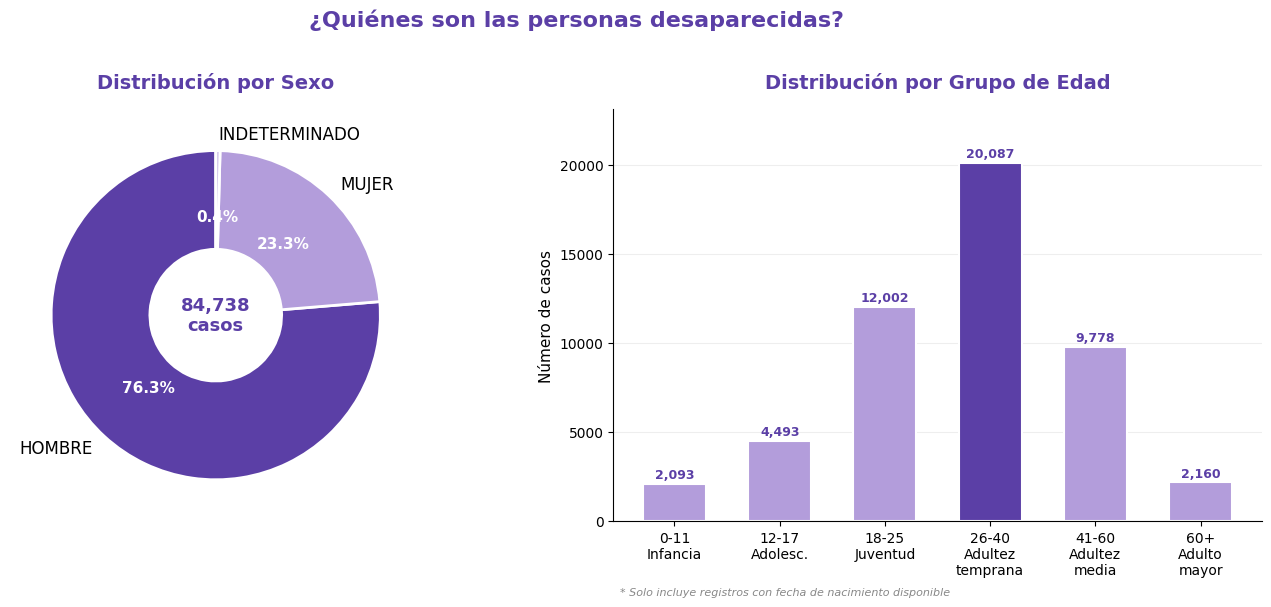

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

# --- Dona de Sexo ---
ax1 = axes[0]
sexo_counts = df_final['SEXO'].value_counts()
labels  = sexo_counts.index.tolist()
sizes   = sexo_counts.values.tolist()
colores = [MORADO, MORADO_CLARO, '#D1C4E9']

wedges, texts, autotexts = ax1.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colores, startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2),
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')

ax1.text(0, 0, f'{sum(sizes):,}\ncasos', ha='center', va='center',
         fontsize=13, fontweight='bold', color=MORADO)
ax1.set_title('Distribución por Sexo', fontsize=14,
              fontweight='bold', color=MORADO, pad=15)

# --- Barras de Grupo de Edad ---
ax2 = axes[1]
edad_orden  = ['0-11', '12-17', '18-25', '26-40', '41-60', '60+']
edad_labels = ['0-11\nInfancia', '12-17\nAdolesc.', '18-25\nJuventud',
               '26-40\nAdultez\ntemprana', '41-60\nAdultez\nmedia', '60+\nAdulto\nmayor']
edad_vals = [df_final['GRUPO_EDAD'].value_counts().get(e, 0) for e in edad_orden]

barras = ax2.bar(edad_labels, edad_vals,
                 color=[MORADO if e == '26-40' else MORADO_CLARO for e in edad_orden],
                 edgecolor='white', linewidth=1.5, width=0.6)

for bar, val in zip(barras, edad_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
             f'{val:,}', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color=MORADO)

ax2.set_title('Distribución por Grupo de Edad', fontsize=14,
              fontweight='bold', color=MORADO, pad=15)
ax2.set_ylabel('Número de casos', fontsize=11)
ax2.set_ylim(0, max(edad_vals) * 1.15)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
ax2.yaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax2.set_axisbelow(True)

ax2.text(0.01, -0.18,
         '* Solo incluye registros con fecha de nacimiento disponible',
         transform=ax2.transAxes, fontsize=8, color='#888888', style='italic')

plt.suptitle('¿Quiénes son las personas desaparecidas?',
             fontsize=16, fontweight='bold', color=MORADO, y=1.02)
plt.tight_layout()
plt.show()

11.2 Top 10 estados con más registros¶

Se destacan Tamaulipas y Michoacán por ser los estados con las reglas de mayor lift.

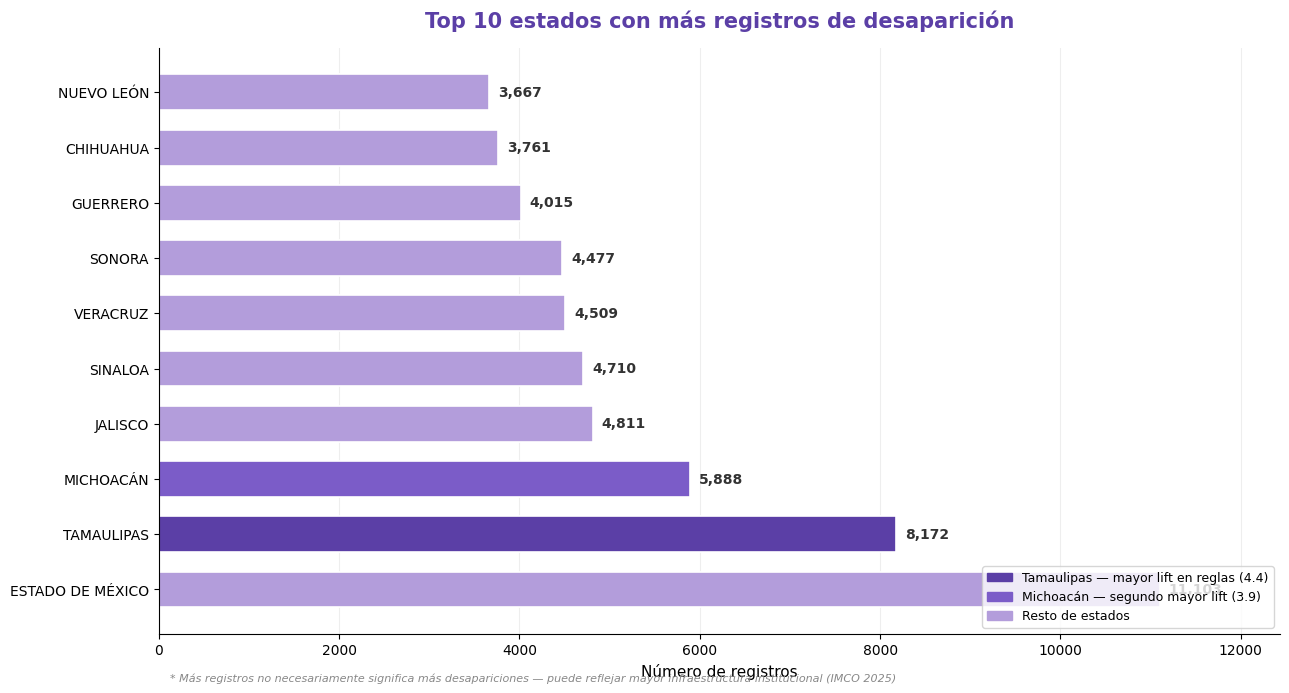

In [47]:
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')

entidad_counts = df_final['ENTIDAD'].value_counts().head(10)
pares = sorted(zip(entidad_counts.values, entidad_counts.index), reverse=True)
valores, estados = zip(*pares)

colores_bar = []
for e in estados:
    if 'TAMAULIPAS' in str(e).upper():   colores_bar.append(MORADO)
    elif 'MICHOAC' in str(e).upper():    colores_bar.append(MORADO2)
    else:                                colores_bar.append(MORADO_CLARO)

barras = ax.barh(estados, valores, color=colores_bar,
                 edgecolor='white', linewidth=1.2, height=0.65)

for bar, val in zip(barras, valores):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10,
            fontweight='bold', color='#333333')

ax.set_xlabel('Número de registros', fontsize=11)
ax.set_title('Top 10 estados con más registros de desaparición',
             fontsize=15, fontweight='bold', color=MORADO, pad=15)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.xaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlim(0, max(valores) * 1.12)

patch1 = mpatches.Patch(color=MORADO,       label='Tamaulipas — mayor lift en reglas (4.4)')
patch2 = mpatches.Patch(color=MORADO2,      label='Michoacán — segundo mayor lift (3.9)')
patch3 = mpatches.Patch(color=MORADO_CLARO, label='Resto de estados')
ax.legend(handles=[patch1, patch2, patch3], loc='lower right', fontsize=9)

ax.text(0.01, -0.08,
        '* Más registros no necesariamente significa más desapariciones — puede reflejar mayor infraestructura institucional (IMCO 2025)',
        transform=ax.transAxes, fontsize=8, color='#888888', style='italic')

plt.tight_layout()
plt.show()

### 11.3 Top 10 reglas por Lift

Las reglas más interesantes — las que ocurren más veces de lo esperado por azar.
La línea roja indica lift=1 (sin asociación).

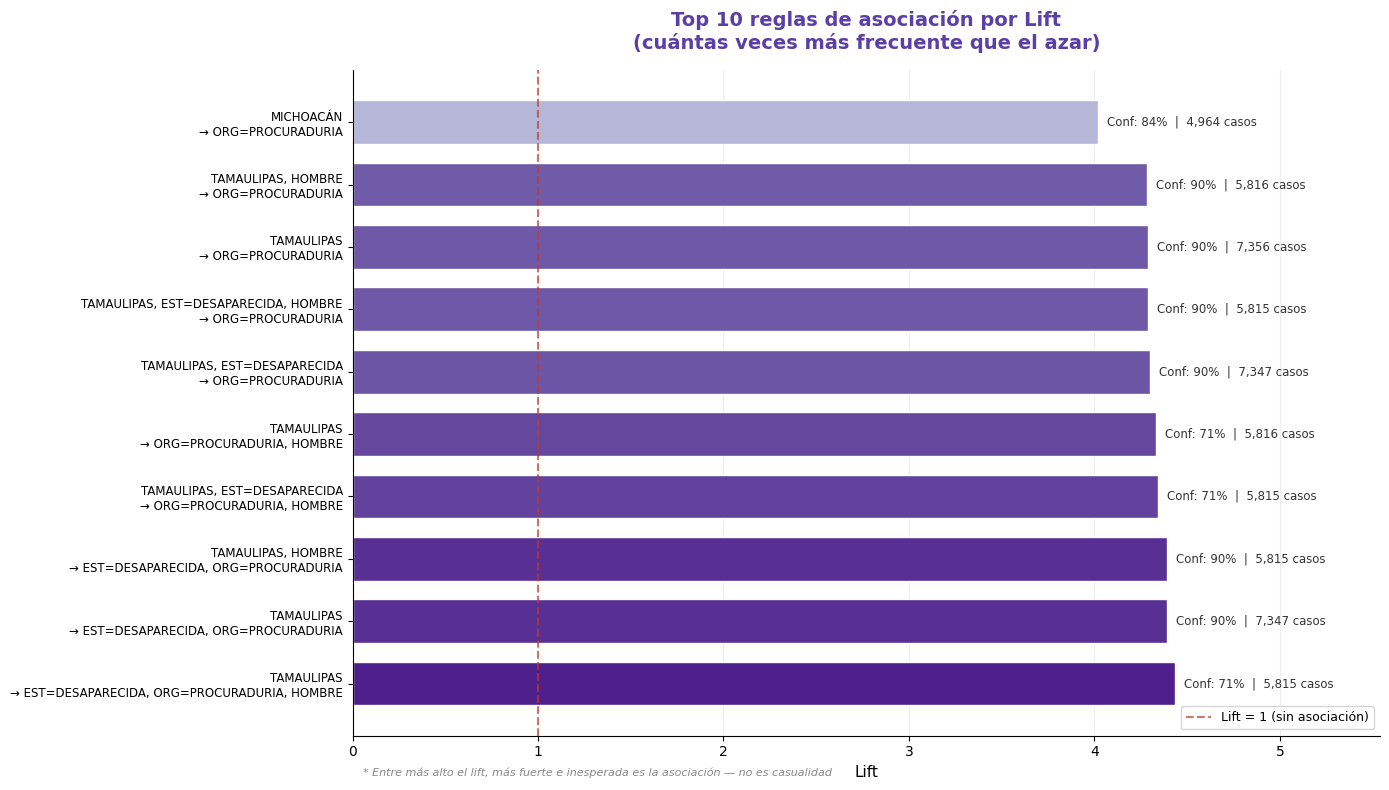

In [48]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')

reglas_vis_full = reglas_mlx.copy()
reglas_vis_full['ant']    = reglas_vis_full['antecedents'].apply(lambda x: ', '.join(sorted(x)))
reglas_vis_full['cons']   = reglas_vis_full['consequents'].apply(lambda x: ', '.join(sorted(x)))
reglas_vis_full['conteo'] = (reglas_vis_full['support'] * len(transacciones)).round().astype(int)

top10 = reglas_vis_full.sort_values('lift', ascending=False).head(10)

def etiqueta_corta(ant, cons):
    ant2  = ant.replace('ENTIDAD=','').replace('ORIGEN_SIMPLIFICADO=','ORG=')
    ant2  = ant2.replace('ESTATUS_VICTIMA=','EST=').replace('SEXO=','')
    ant2  = ant2.replace('GRUPO_EDAD=','EDAD=')
    cons2 = cons.replace('ENTIDAD=','').replace('ORIGEN_SIMPLIFICADO=','ORG=')
    cons2 = cons2.replace('ESTATUS_VICTIMA=','EST=').replace('SEXO=','')
    return f"{ant2}\n→ {cons2}"

etiquetas = [etiqueta_corta(row['ant'], row['cons']) for _, row in top10.iterrows()]
lifts     = top10['lift'].tolist()
confs     = top10['confidence'].tolist()
conteos   = top10['conteo'].tolist()

norm_lift    = [(l - min(lifts)) / (max(lifts) - min(lifts)) for l in lifts]
colores_lift = [plt.cm.Purples(0.4 + 0.5 * n) for n in norm_lift]

barras = ax.barh(range(len(etiquetas)), lifts,
                 color=colores_lift, edgecolor='white', linewidth=1, height=0.7)

ax.axvline(x=1, color=ROJO, linewidth=1.5, linestyle='--',
           alpha=0.7, label='Lift = 1 (sin asociación)')

for i, (bar, conf, cnt) in enumerate(zip(barras, confs, conteos)):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'Conf: {conf:.0%}  |  {cnt:,} casos',
            va='center', fontsize=8.5, color='#333333')

ax.set_yticks(range(len(etiquetas)))
ax.set_yticklabels(etiquetas, fontsize=8.5)
ax.set_xlabel('Lift', fontsize=11)
ax.set_title('Top 10 reglas de asociación por Lift\n(cuántas veces más frecuente que el azar)',
             fontsize=14, fontweight='bold', color=MORADO, pad=15)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.xaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlim(0, max(lifts) * 1.25)
ax.legend(fontsize=9, loc='lower right')

ax.text(0.01, -0.06,
        '* Entre más alto el lift, más fuerte e inesperada es la asociación — no es casualidad',
        transform=ax.transAxes, fontsize=8, color='#888888', style='italic')

plt.tight_layout()
plt.show()

## 12. Conclusiones

### Comparación de algoritmos
| Criterio | Apriori Propio | Apriori mlxtend | FP-Growth mlxtend |
|----------|---------------|-----------------|-------------------|
| Velocidad | Más lento | Intermedio | Más rápido |
| Mismas reglas | Sí | Sí | Sí |
| Razón | Python puro, loops | NumPy vectorizado | FP-Tree, 2 escaneos |

### Limitaciones del análisis
1. **37% de datos excluidos** por ser CONFIDENCIAL — los patrones aplican solo al 63% público
2. **40% sin edad calculable** — las reglas con GRUPO_EDAD son sobre un subconjunto menor
3. **El dataset refleja el sistema de registro**, no la realidad completa del fenómeno
4. **Reglas de asociación ≠ causalidad** — una asociación fuerte no implica que un factor cause el otro

### Lo que sí nos dicen las reglas
Las reglas con lift > 1 identifican combinaciones de factores que co-ocurren con más 
frecuencia de la esperada por azar, lo que puede ser útil para diseñar políticas 
focalizadas de búsqueda y prevención.